In [1]:
import os
os.chdir("../")
%pwd

'/Users/kiranprasadjp/Documents/Pros/NeuronWireTracingEngine'

In [2]:
from dataclasses import dataclass
from pathlib import Path


@dataclass(frozen=True)
class DataIngestionConfig:
    root_dir: Path
    source_URL: str
    local_data_file: Path
    unzip_dir: Path

In [5]:
from src.neuronTracer import *
from src.neuronTracer.constants import *
from src.neuronTracer.utils.common import read_yaml, create_directories

In [ ]:
class ConfigurationManager:
    def __init__(
        self,
        config_filepath = CONFIG_FILE_PATH,
        params_filepath = PARAMS_FILE_PATH):

        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)

        create_directories([self.config.artifacts_root])


    
    def get_data_ingestion_config(self) -> DataIngestionConfig:
        config = self.config.data_ingestion

        create_directories([config.root_dir])

        data_ingestion_config = DataIngestionConfig(
            root_dir= Path(config.root_dir),
            source_URL= Path(config.source_URL),
            local_data_file=Path(config.local_data_file),
            unzip_dir=Path(config.unzip_dir) 
        )

        return data_ingestion_config

In [11]:
import os
import urllib.request as request
import zipfile
from src.neuronTracer import logger
from src.neuronTracer.utils.common import get_size

In [12]:
class DataIngestion:
    def __init__(self, config: DataIngestionConfig):
        self.config = config

    
    def download_file(self)-> str:
        '''
        Fetch data from the url
        '''

        try: 
            dataset_url = self.config.source_URL
            local_file_path= self.config.local_data_file

            os.makedirs(os.path.dirname(local_file_path), exist_ok=True)
            # 2. Check if file already exists to save time/bandwidth
            if not os.path.exists(local_file_path):
                logger.info(f"Starting download from {dataset_url}...")
            
                # Use urllib for a clean, direct download
                filename, headers = request.urlretrieve(
                    url = dataset_url,
                    filename = local_file_path
                )
                logger.info(f"Download complete! File saved as: {filename}")
                logger.info(f"Info from server: \n{headers}")
            else:
                logger.info(f"File already exists of size: {get_size(Path(local_file_path))}")

        except Exception as e:
            logger.error(f"Error occurred while downloading: {e}")
            raise e


    
    def extract_zip_file(self):
        """
        zip_file_path: str
        Extracts the zip file into the data directory
        Function returns None
        """
        unzip_path = self.config.unzip_dir
        os.makedirs(unzip_path, exist_ok=True)
        with zipfile.ZipFile(self.config.local_data_file, 'r') as zip_ref:
            zip_ref.extractall(unzip_path)

In [13]:
try:
    config = ConfigurationManager()
    data_ingestion_config = config.get_data_ingestion_config()
    data_ingestion = DataIngestion(config=data_ingestion_config)
    data_ingestion.download_file()
    data_ingestion.extract_zip_file()
except Exception as e:
    raise e

[2026-03-21 22:55:47,603: INFO: common: yaml file: config/config.yaml loaded successfully]
[2026-03-21 22:55:47,606: INFO: common: yaml file: params.yaml loaded successfully]
[2026-03-21 22:55:47,606: INFO: common: created directory at: artifacts]
[2026-03-21 22:55:47,618: INFO: common: created directory at: artifacts/data_ingestion]
[2026-03-21 22:55:47,621: INFO: 4023874001: Starting download from https://zenodo.org/records/7142003/files/snemi.zip...]
[2026-03-21 22:55:56,841: INFO: 4023874001: Download complete! File saved as: artifacts/data_ingestion/snemi.zip]
[2026-03-21 22:55:56,846: INFO: 4023874001: Info from server: 
server: nginx
date: Sun, 22 Mar 2026 02:55:48 GMT
content-type: application/octet-stream
content-length: 194608530
content-disposition: attachment; filename=snemi.zip
set-cookie: session=2489dcc183ff9ba_69bf5a34.gcyKM9QPeIG8VcoZzV4ak2VlQdE; Expires=Fri, 27 Mar 2026 02:55:48 GMT; Secure; HttpOnly; Path=/; SameSite=Lax
oc-checksum: MD5:3d25a7025f66698f33c7850ace885

In [3]:

import tifffile
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import numpy as np

In [4]:
em     = tifffile.imread('artifacts/data_ingestion/image/train-input.tif')      # (100, 1024, 1024) uint8
labels = tifffile.imread('artifacts/data_ingestion/seg/train-labels.tif')  
print(f"EM shape:     {em.shape},     dtype: {em.dtype}")
print(f"Labels shape: {labels.shape}, dtype: {labels.dtype}")
print(f"Unique neurons: {np.unique(labels).shape[0]}")

EM shape:     (100, 1024, 1024),     dtype: uint8
Labels shape: (100, 1024, 1024), dtype: uint16
Unique neurons: 401


🔬 Loading 3D scan: final_submission.tif...
✅ Successfully loaded! This block is 100 slices deep.
🚀 Opening the visualizer window. Close the window to stop the script.


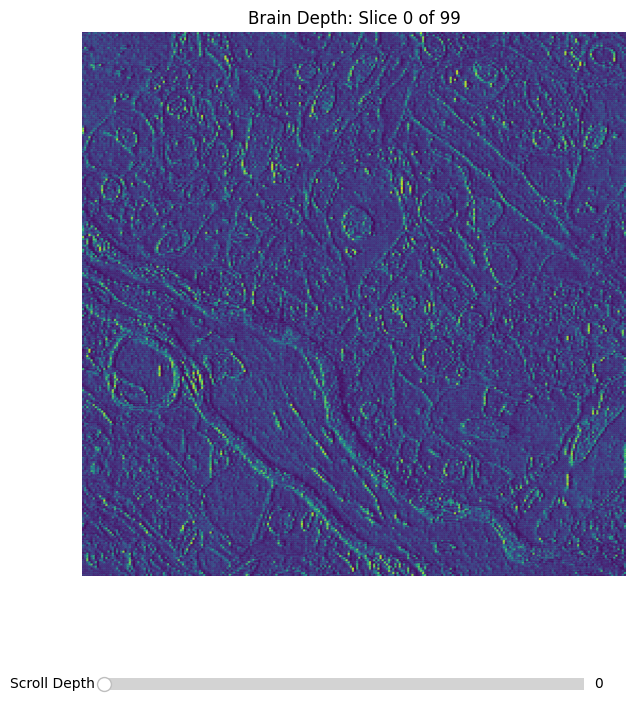

In [4]:
import tifffile
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import numpy as np

def visualize_brain_scan(file_path):
    print(f"🔬 Loading 3D scan: {file_path}...")
    
    try:
        brain_volume = tifffile.imread(file_path)
    except FileNotFoundError:
        print(f"❌ Error: Could not find '{file_path}'. Make sure the file is in this folder.")
        return

    total_slices = brain_volume.shape[0]
    print(f"✅ Successfully loaded! This block is {total_slices} slices deep.")

    fig, ax = plt.subplots(figsize=(8, 8))
    plt.subplots_adjust(bottom=0.2) 

    display_image = ax.imshow(brain_volume[0], cmap='viridis')
    ax.set_title(f"Brain Depth: Slice 0 of {total_slices - 1}")
    ax.axis('off') 

    ax_slider = plt.axes([0.2, 0.05, 0.6, 0.03])
    depth_slider = Slider(
        ax=ax_slider, 
        label='Scroll Depth', 
        valmin=0, 
        valmax=total_slices - 1, 
        valinit=0, 
        valstep=1
    )

    def update_screen(val):
        current_slice = int(depth_slider.val)
        display_image.set_data(brain_volume[current_slice])
        ax.set_title(f"Brain Depth: Slice {current_slice} of {total_slices - 1}")
        fig.canvas.draw_idle()

    depth_slider.on_changed(update_screen)

    # 🔥 THE FIX: Glue the slider to the figure so Python's Garbage Collector doesn't delete it
    fig.slider = depth_slider

    print("🚀 Opening the visualizer window. Close the window to stop the script.")
    plt.show()

if __name__ == "__main__":
    TARGET_FILE = "final_submission.tif" 
    visualize_brain_scan(TARGET_FILE)

In [3]:
import neuroglancer
import tifffile
import numpy as np
import os

def launch_neuroglancer(raw_image_path, prediction_path):
    print("Setting up Neuroglancer Web Server...")
    
    # 1. Initialize the local server on your machine
    neuroglancer.set_server_bind_address('127.0.0.1', bind_port=8080)
    viewer = neuroglancer.Viewer()

    # 2. Load the 3D TIF files into memory
    print(f"Loading Raw EM Scan: {raw_image_path}")
    if os.path.exists(raw_image_path):
        raw_data = tifffile.imread(raw_image_path)
    else:
        print(f"⚠️ Could not find raw image. Using a blank canvas.")
        raw_data = np.zeros((100, 1024, 1024), dtype=np.uint8)

    print(f"Loading AI Prediction: {prediction_path}")
    if os.path.exists(prediction_path):
        pred_data = tifffile.imread(prediction_path)
        # Neuroglancer requires Segmentation layers to be uint32 or uint64
        binary_pred = (pred_data > 0.5).astype(np.uint32) 
    else:
        print(f"⚠️ Could not find prediction. Using a blank canvas.")
        binary_pred = np.zeros_like(raw_data, dtype=np.uint32)

    # 3. Define the physical dimensions of the SNEMI3D data (Z, Y, X)
    # This prevents the 3D volume from looking stretched or squashed
    dimensions = neuroglancer.CoordinateSpace(
        names=['z', 'y', 'x'],
        units='nm',
        scales=[40, 4, 4] # SNEMI3D is typically 40nm deep, 4nm wide/high per pixel
    )

    # 4. Mount the data to the web viewer
    with viewer.txn() as s:
        # Add the raw black-and-white biological image
        s.layers['Raw Brain Tissue'] = neuroglancer.ImageLayer(
            source=neuroglancer.LocalVolume(
                data=raw_data,
                dimensions=dimensions,
            ),
        )
        
        # Add the AI's drawing as a neon overlay
        s.layers['AI Cell Walls'] = neuroglancer.SegmentationLayer(
            source=neuroglancer.LocalVolume(
                data=binary_pred,
                dimensions=dimensions,
            ),
            # Optional: Make the lines slightly transparent so you can see the biology underneath
            segments=[1], 
        )

    # 5. Provide the viewing link
    print("\n" + "="*50)
    print("🚀 NEUROGLANCER IS LIVE!")
    print(f"Click this link to open the 3D viewer in your browser:")
    print(viewer.get_viewer_url())
    print("="*50 + "\n")
    
    # Keep the script running so the server doesn't shut down
    input("Press [ENTER] in this terminal to shut down the server...")

if __name__ == "__main__":
    # Point these to your actual files
    RAW_SCAN = "artifacts/data_ingestion/image/test-input.tif" # Update this to your raw test image path
    AI_PREDICTION = "final_submission.tif"
    
    launch_neuroglancer(RAW_SCAN, AI_PREDICTION)

Setting up Neuroglancer Web Server...
Loading Raw EM Scan: artifacts/data_ingestion/image/test-input.tif
Loading AI Prediction: final_submission.tif

🚀 NEUROGLANCER IS LIVE!
Click this link to open the 3D viewer in your browser:
http://127.0.0.1:8080/v/6fedd38fe0424b2f92678a097ec0b8ff44106d1d/

